In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

insurance = pd.read_csv("insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
#Identify the shape of the dataset, data types of each column, and check for missing values
print(f"Dataset shape: {insurance.shape}")
print("\nColumn data types:")
print(insurance.dtypes)
print("\nMissing values:")
print(insurance.isna().sum())

# The target is personal medical cost (charges); all other columns are features.
X = insurance.drop(columns="charges")
y = insurance["charges"]

print("\nFeatures:", list(X.columns))
print("Target: charges")

Dataset shape: (1338, 7)

Column data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Target: charges


In [3]:
# Split the dataset into training and testing sets (80% training, 20% testing).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

categorical_features = ["sex", "smoker", "region"]
numerical_features = ["age", "bmi", "children"]

# One-hot encode categorical columns and standardize numeric columns.
# Scaling is especially important for SVR because it uses distances in feature space.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1070
Testing samples: 268


In [4]:
# Train a multiple linear regression model using a pipeline that includes preprocessing.
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
print("Multiple linear regression model trained successfully.")

Multiple linear regression model trained successfully.


In [5]:
# Evaluate the model using R-squared, Mean Squared Error (MSE), and Mean Absolute Error (MAE).
def regression_metrics(actual, predicted):
    return {
        "R-squared": r2_score(actual, predicted),
        "MSE": mean_squared_error(actual, predicted),
        "MAE": mean_absolute_error(actual, predicted),
    }

linear_results = regression_metrics(y_test, linear_predictions)
linear_results_df = pd.DataFrame([linear_results], index=["Multiple Linear Regression"])
linear_results_df

,R-squared,MSE,MAE
Multiple Linear Regression,0.783593,3.359692e+07,4181.194474


In [6]:
# Construct and tune the SVR model
svr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", SVR()),
    ]
)

parameter_grid = {
    "regressor__kernel": ["rbf"],
    "regressor__C": [100, 1000, 10000],
    "regressor__epsilon": [0.1, 0.2, 0.5],
    "regressor__gamma": ["scale", "auto"],
}

svr_search = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=parameter_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
svr_search.fit(X_train, y_train)
svr_predictions = svr_search.predict(X_test)

print("Best SVR parameters:")
print(svr_search.best_params_)

Best SVR parameters:
{'regressor__C': 10000, 'regressor__epsilon': 0.5, 'regressor__gamma': 'scale', 'regressor__kernel': 'rbf'}


In [7]:
# Evaluate The SVR model using R-squared, Mean Squared Error (MSE), and Mean Absolute Error (MAE).
svr_results = regression_metrics(y_test, svr_predictions)
svr_results_df = pd.DataFrame([svr_results], index=["Support Vector Regression"])
svr_results_df

,R-squared,MSE,MAE
Support Vector Regression,0.849604,2.334881e+07,1803.299218


In [8]:
# Compare Model perfomance metrics side by side
comparison = pd.concat([linear_results_df, svr_results_df])
comparison

,R-squared,MSE,MAE
Multiple Linear Regression,0.783593,3.359692e+07,4181.194474
Support Vector Regression,0.849604,2.334881e+07,1803.299218


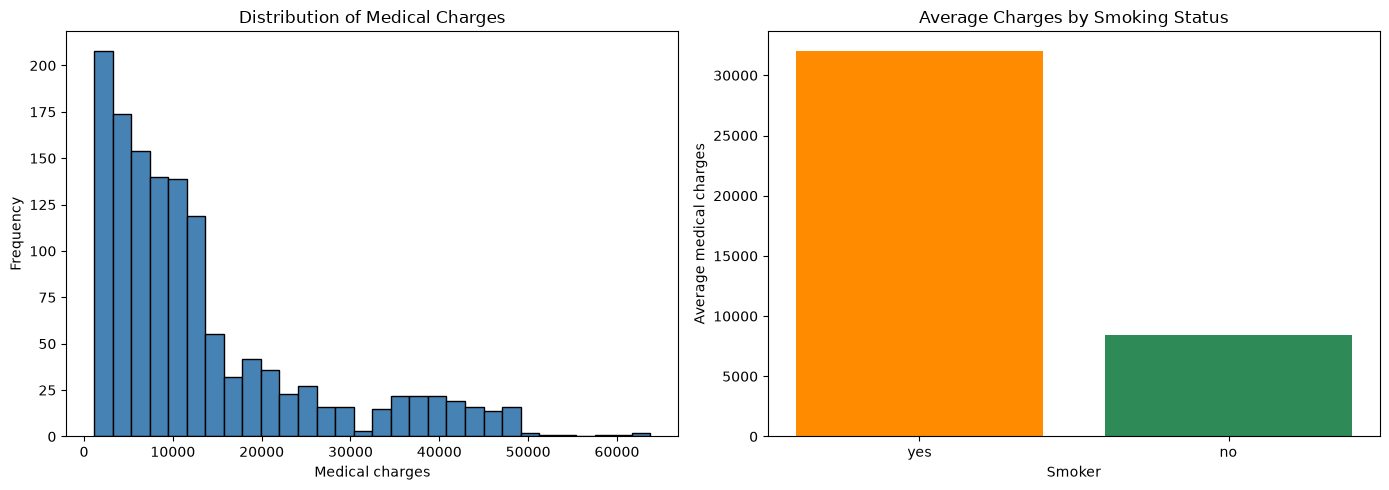

In [9]:
# Visualze the dataset and model predistiona 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(insurance["charges"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of Medical Charges")
axes[0].set_xlabel("Medical charges")
axes[0].set_ylabel("Frequency")

smoker_means = insurance.groupby("smoker")["charges"].mean().sort_values(ascending=False)
axes[1].bar(smoker_means.index, smoker_means.values, color=["darkorange", "seagreen"])
axes[1].set_title("Average Charges by Smoking Status")
axes[1].set_xlabel("Smoker")
axes[1].set_ylabel("Average medical charges")

plt.tight_layout()
plt.show()

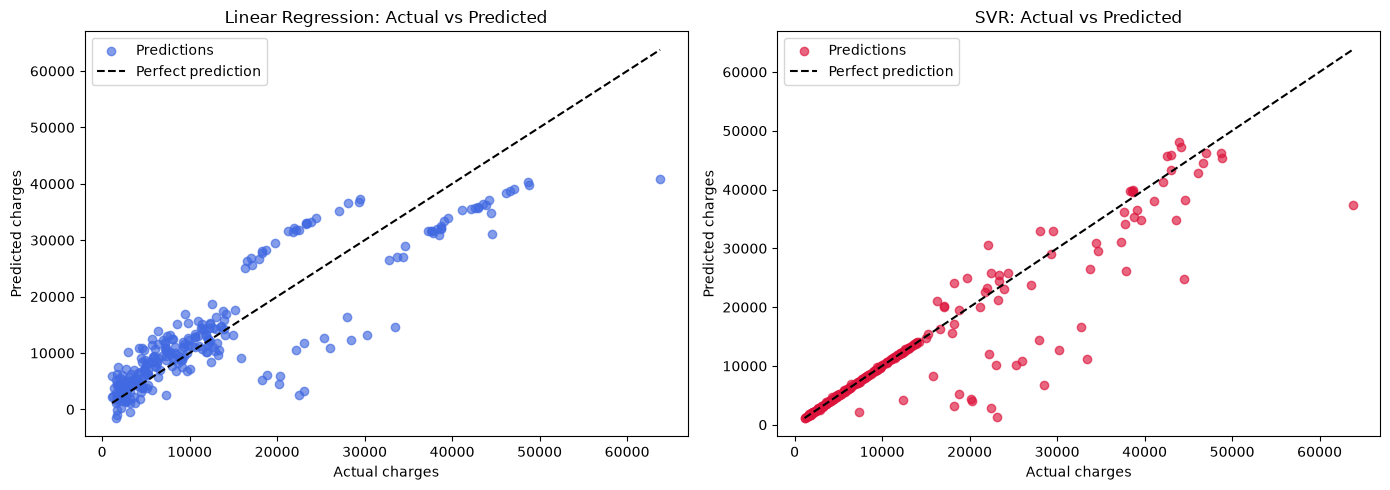

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, linear_predictions, alpha=0.65, color="royalblue", label="Predictions")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", label="Perfect prediction")
axes[0].set_title("Linear Regression: Actual vs Predicted")
axes[0].set_xlabel("Actual charges")
axes[0].set_ylabel("Predicted charges")
axes[0].legend()

axes[1].scatter(y_test, svr_predictions, alpha=0.65, color="crimson", label="Predictions")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", label="Perfect prediction")
axes[1].set_title("SVR: Actual vs Predicted")
axes[1].set_xlabel("Actual charges")
axes[1].set_ylabel("Predicted charges")
axes[1].legend()

plt.tight_layout()
plt.show()

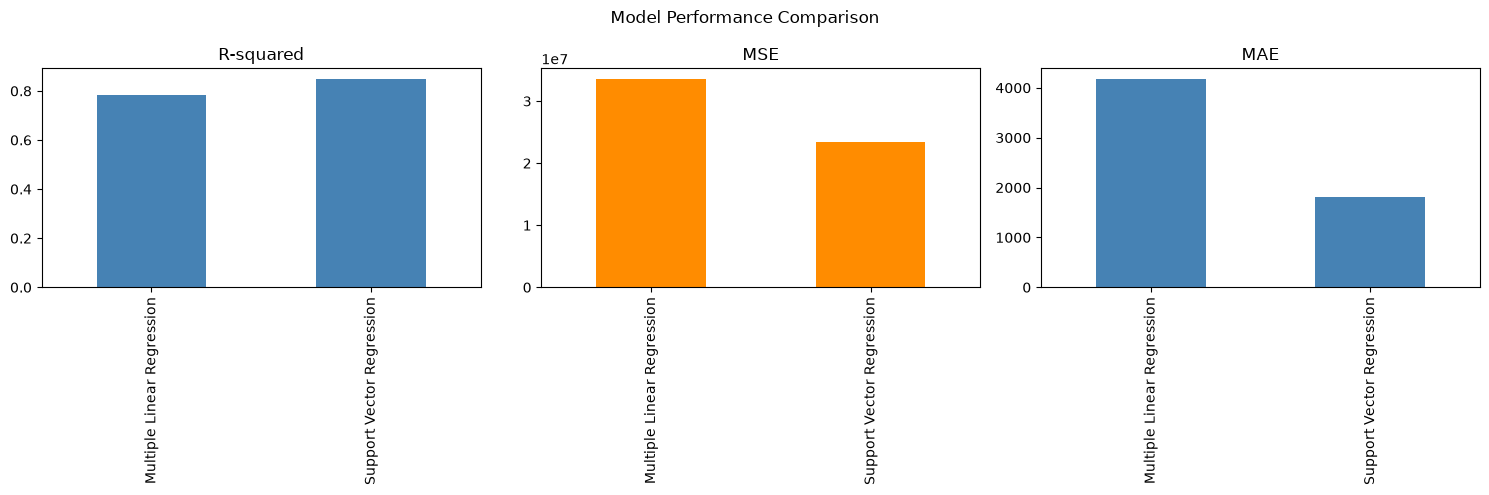

In [11]:
comparison.plot(kind="bar", subplots=True, layout=(1, 3), figsize=(15, 5), legend=False, color=["steelblue", "darkorange"])
plt.suptitle("Model Performance Comparison")
plt.tight_layout()
plt.show()